In [1]:
!pip -q install pennylane scipy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 52.2 MB/s eta 0:00:00


In [2]:
import pennylane as qml
import pennylane.numpy as np

import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [3]:
# ==========================================
# Experiment Settings
# ==========================================

QUBIT_COUNTS = [8, 10, 12]

FRACTIONS = [
    0.2,
    0.4,
    0.6,
    0.8,
    1.0
]

MAX_DEPTH = 25

N_SAMPLES = 40

In [4]:
# ==========================================
# Brick-Wall Circuit
#
# Even Layers:
# (0,1) (2,3) (4,5) ...
#
# Odd Layers:
# (1,2) (3,4) (5,6) ...
#
# ==========================================

def BrickWall_HEA(
    n_qubits,
    params,
    depth
):

    idx = 0

    for d in range(depth):

        # Rotation Layer

        for q in range(n_qubits):

            qml.RY(
                params[idx],
                wires=q
            )

            idx += 1

        # Entangling Layer

        if d % 2 == 0:

            for q in range(
                0,
                n_qubits - 1,
                2
            ):

                qml.CNOT(
                    wires=[q, q + 1]
                )

        else:

            for q in range(
                1,
                n_qubits - 1,
                2
            ):

                qml.CNOT(
                    wires=[q, q + 1]
                )

In [5]:
# ==========================================
# Observable Support
#
# k=1:
# Z0
#
# k=2:
# Z0 Z1
#
# k=4:
# Z0 Z1 Z2 Z3
#
# etc
#
# ==========================================

def make_observable(k):

    op = qml.PauliZ(0)

    for q in range(1, k):

        op = op @ qml.PauliZ(q)

    return op

In [6]:
# ==========================================
# Extract tau_BP
# ==========================================

def compute_tau_bp_fit(
    variances,
    depths
):

    variances = np.array(variances)

    depths = np.array(depths)

    valid = variances > 1e-12

    variances = variances[valid]

    depths = depths[valid]

    slope, intercept = np.polyfit(
        depths,
        np.log(variances),
        1
    )

    alpha = -slope

    tau = 1 / alpha

    return tau, alpha

In [7]:
# ==========================================
# MAIN EXPERIMENT
#
# Computes tau_BP
# for each:
#
# n
# k/n
#
# ==========================================

collapse_results = {}

for n in QUBIT_COUNTS:

    print("\n")
    print("="*60)
    print(f"n = {n}")
    print("="*60)

    dev = qml.device(
        "default.qubit",
        wires=n
    )

    collapse_results[n] = {}

    k_values = sorted(
        set(
            max(
                1,
                int(round(frac * n))
            )
            for frac in FRACTIONS
        )
    )

    for k in k_values:

        frac = k / n

        print(
            f"\nRunning:"
            f" n={n}"
            f" k={k}"
            f" k/n={frac:.2f}"
        )

        @qml.qnode(dev)
        def cost_fn(
            params,
            depth
        ):

            BrickWall_HEA(
                n,
                params,
                depth
            )

            return qml.expval(
                make_observable(k)
            )

        gradient_variances = []

        for depth in range(
            1,
            MAX_DEPTH + 1
        ):

            grads_all = []

            for sample in range(
                N_SAMPLES
            ):

                params = np.random.uniform(
                    0,
                    2*np.pi,
                    size=depth*n,
                    requires_grad=True
                )

                grads = qml.grad(
                    cost_fn
                )(
                    params,
                    depth
                )

                grads_all.extend(
                    grads
                )

            variance = np.var(
                grads_all
            )

            gradient_variances.append(
                variance
            )

        tau, alpha = compute_tau_bp_fit(
            gradient_variances,
            range(
                1,
                MAX_DEPTH + 1
            )
        )

        collapse_results[n][frac] = {

            "k": k,

            "tau": tau,

            "alpha": alpha
        }

        print(
            f"tau_BP={tau:.3f}"
            f" alpha={alpha:.4f}"
        )



n = 8

Running: n=8 k=2 k/n=0.25
tau_BP=11.057 alpha=0.0904

Running: n=8 k=3 k/n=0.38
tau_BP=11.140 alpha=0.0898

Running: n=8 k=5 k/n=0.62
tau_BP=13.863 alpha=0.0721

Running: n=8 k=6 k/n=0.75
tau_BP=14.487 alpha=0.0690

Running: n=8 k=8 k/n=1.00
tau_BP=23.947 alpha=0.0418


n = 10

Running: n=10 k=2 k/n=0.20
tau_BP=10.525 alpha=0.0950

Running: n=10 k=4 k/n=0.40
tau_BP=9.003 alpha=0.1111

Running: n=10 k=6 k/n=0.60
tau_BP=9.736 alpha=0.1027

Running: n=10 k=8 k/n=0.80
tau_BP=11.412 alpha=0.0876

Running: n=10 k=10 k/n=1.00
tau_BP=19.900 alpha=0.0503


n = 12

Running: n=12 k=2 k/n=0.17
tau_BP=9.968 alpha=0.1003

Running: n=12 k=5 k/n=0.42
tau_BP=8.866 alpha=0.1128

Running: n=12 k=7 k/n=0.58
tau_BP=7.677 alpha=0.1303

Running: n=12 k=10 k/n=0.83
tau_BP=10.234 alpha=0.0977

Running: n=12 k=12 k/n=1.00
tau_BP=15.084 alpha=0.0663


In [8]:
print("\n")
....................................
for n in collapse_results:

    print("\n")
    print(f"n = {n}")

    for frac in sorted(
        collapse_results[n]
    ):

        r = collapse_results[n][frac]

        print(
            f"k={r['k']:2d} "
            f"k/n={frac:.2f} "
            f"tau={r['tau']:.3f}"
        )





n = 8
k= 2 k/n=0.25 tau=11.057
k= 3 k/n=0.38 tau=11.140
k= 5 k/n=0.62 tau=13.863
k= 6 k/n=0.75 tau=14.487
k= 8 k/n=1.00 tau=23.947


n = 10
k= 2 k/n=0.20 tau=10.525
k= 4 k/n=0.40 tau=9.003
k= 6 k/n=0.60 tau=9.736
k= 8 k/n=0.80 tau=11.412
k=10 k/n=1.00 tau=19.900


n = 12
k= 2 k/n=0.17 tau=9.968
k= 5 k/n=0.42 tau=8.866
k= 7 k/n=0.58 tau=7.677
k=10 k/n=0.83 tau=10.234
k=12 k/n=1.00 tau=15.084


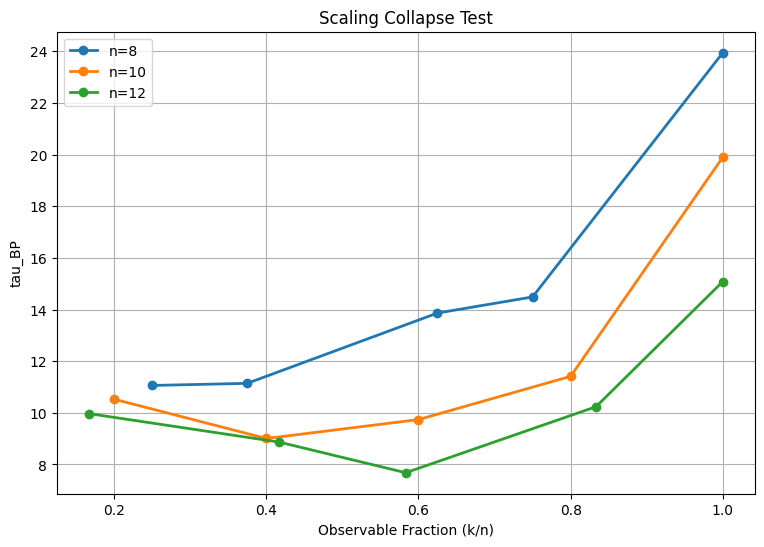

In [9]:
plt.figure(
    figsize=(9,6)
)

for n in collapse_results:

    xs = []
    ys = []

    for frac in sorted(
        collapse_results[n]
    ):

        xs.append(frac)

        ys.append(
            collapse_results[n][frac]["tau"]
        )

    plt.plot(
        xs,
        ys,
        marker="o",
        linewidth=2,
        label=f"n={n}"
    )

plt.xlabel(
    "Observable Fraction (k/n)"
)

plt.ylabel(
    "tau_BP"
)

plt.title(
    "Scaling Collapse Test"
)

plt.legend()

plt.grid(True)

plt.show()

Running k=2...
Running k=10...


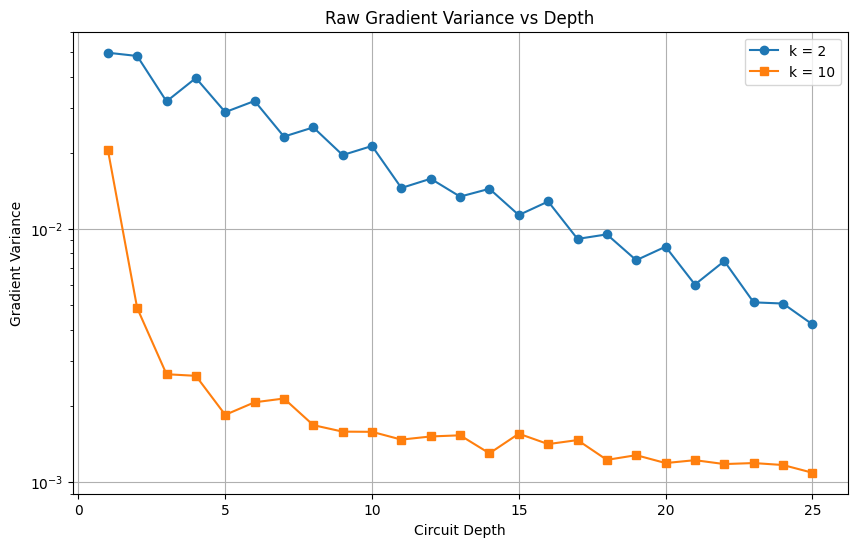

In [10]:
# ==========================================
# DIAGNOSTIC:
#
# Compare raw gradient variance curves
#
# n = 10
#
# k = 2
# k = 10
#
# NO FITTING
# NO tau_BP
#
# Just raw variance vs depth
#
# ==========================================

N_QUBITS = 10

MAX_DEPTH = 25

N_SAMPLES = 50

dev = qml.device(
    "default.qubit",
    wires=N_QUBITS
)

# ------------------------------------------
# Cost circuit generator
# ------------------------------------------

def make_cost_circuit(k):

    @qml.qnode(dev)
    def cost_fn(params, depth):

        BrickWall_HEA(
            N_QUBITS,
            params,
            depth
        )

        return qml.expval(
            make_observable(k)
        )

    return cost_fn


cost_k2 = make_cost_circuit(2)

cost_k10 = make_cost_circuit(10)


# ------------------------------------------
# Compute variance curve
# ------------------------------------------

def variance_curve(cost_fn):

    variances = []

    for depth in range(
        1,
        MAX_DEPTH + 1
    ):

        grads_all = []

        for _ in range(
            N_SAMPLES
        ):

            params = np.random.uniform(
                0,
                2*np.pi,
                size=depth * N_QUBITS,
                requires_grad=True
            )

            grads = qml.grad(
                cost_fn
            )(
                params,
                depth
            )

            grads_all.extend(
                grads
            )

        variances.append(
            np.var(grads_all)
        )

    return variances


print("Running k=2...")
var_k2 = variance_curve(
    cost_k2
)

print("Running k=10...")
var_k10 = variance_curve(
    cost_k10
)


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(10,6))

plt.plot(
    range(1, MAX_DEPTH+1),
    var_k2,
    marker="o",
    label="k = 2"
)

plt.plot(
    range(1, MAX_DEPTH+1),
    var_k10,
    marker="s",
    label="k = 10"
)

plt.yscale("log")

plt.xlabel("Circuit Depth")

plt.ylabel("Gradient Variance")

plt.title(
    "Raw Gradient Variance vs Depth"
)

plt.legend()

plt.grid(True)

plt.show()

In [11]:
print("\nFirst few k=2 values:")
print(var_k2[:10])

print("\nFirst few k=10 values:")
print(var_k10[:10])


First few k=2 values:
[np.float64(0.04967198376290327), np.float64(0.04821967040938614), np.float64(0.031898361854115403), np.float64(0.03946142241686068), np.float64(0.028937306433879133), np.float64(0.03202726694893776), np.float64(0.02315979640338491), np.float64(0.025183447000384752), np.float64(0.01957531139514918), np.float64(0.021264100659637814)]

First few k=10 values:
[np.float64(0.0205874157391882), np.float64(0.00486840808799466), np.float64(0.002665465240250441), np.float64(0.002626847592771389), np.float64(0.0018421553811646852), np.float64(0.00206499164048101), np.float64(0.0021370590393315933), np.float64(0.001677458677041654), np.float64(0.001581109917968603), np.float64(0.0015783414855709335)]
